# Разбор диагностического отчёта iOS (.ips)

Читаем шапки двух отчётов о превышении лимита записи на диск и сравниваем приложение VK с системной службой Apple.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_ips(path):
    text = open(path, encoding='utf-8', errors='ignore').read()
    get = lambda key: (re.search(rf'^{key}:\s+(.+)$', text, re.M) or [None, None])[1]
    writes = re.search(r'([\d.]+) MB of file backed memory dirtied over (\d+) seconds \(([\d.]+) KB per second average\), exceeding limit of ([\d.]+) KB', text)
    return {
        'Процесс': get('Command'),
        'Начало': get('Date/Time'),
        'Конец': get('End time'),
        'Записано, МБ': float(writes[1]),
        'За часов': round(int(writes[2]) / 3600, 1),
        'Скорость, КБ/с': float(writes[3]),
        'Лимит, КБ/с': float(writes[4]),
    }

df = pd.DataFrame([parse_ips('VKClient_diskwrites_resource-2026-09-16-170257.ips'),
                   parse_ips('ANECompilerService_diskwrites_header.txt')])
df['Превышение, раз'] = (df['Скорость, КБ/с'] / df['Лимит, КБ/с']).round(2)
df

,Процесс,Начало,Конец,"Записано, МБ",За часов,"Скорость, КБ/с","Лимит, КБ/с","Превышение, раз"
0,VKClient,2026-09-16 11:59:38.403 +0300,2026-09-16 17:02:51.923 +0300,1074.25,5.1,59.05,12.43,4.75
1,ANECompilerService,2026-09-15 16:01:51.801 +0300,2026-09-16 04:56:42.984 +0300,1073.76,12.9,23.10,12.43,1.86


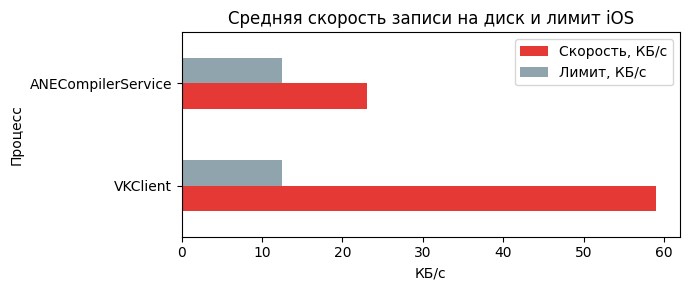

In [2]:
ax = df.set_index('Процесс')[['Скорость, КБ/с', 'Лимит, КБ/с']].plot.barh(color=['#E53935', '#90A4AE'], figsize=(7, 3))
ax.set_xlabel('КБ/с'); ax.set_title('Средняя скорость записи на диск и лимит iOS')
plt.tight_layout(); plt.show()

In [3]:
text = open('VKClient_diskwrites_resource-2026-09-16-170257.ips', encoding='utf-8').read()
stack = text.split('Heaviest stack for the target process:')[1].split('Powerstats')[0]
libs = pd.Series(re.findall(r'\(([\w.]+\.dylib)', stack)).value_counts()
print('Библиотеки в самом тяжёлом стеке VK:'); libs

Библиотеки в самом тяжёлом стеке VK:


libdispatch.dylib          9
libsqlite3.dylib           8
libsystem_pthread.dylib    2
libsystem_kernel.dylib     1
Name: count, dtype: int64

## Вывод

VK записал 1 ГБ за 5 часов дневной работы от батареи: в 4,75 раза быстрее лимита iOS. В тяжёлом стеке видна `libsqlite3.dylib`, то есть пишет база данных приложения. Системная служба Apple превысила тот же лимит заметно мягче и ночью, во время фоновых задач.